# 📝 EDA - Text Data: Stanford Question Answering Dataset (SQuAD)
**Course:** P4AI-DS (CO3135) - HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [SQuAD 1.1](https://huggingface.co/datasets/rajpurkar/squad)

**Mô tả:** 100,000+ cặp câu hỏi-trả lời dựa trên bài viết Wikipedia.

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from datasets import load_dataset
from wordcloud import WordCloud
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

print('✅ Import thành công!')

✅ Import thành công!


## 2. Load dữ liệu từ HuggingFace

In [2]:
print('📥 Đang tải dataset SQuAD 1.1...')
dataset = load_dataset('rajpurkar/squad')
print('✅ Tải thành công!')
print(dataset)

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
df = pd.concat([train_df, val_df], ignore_index=True)

print(f'\n🔹 Training set: {len(train_df)} mẫu')
print(f'🔹 Validation set: {len(val_df)} mẫu')
print(f'🔹 Tổng cộng: {len(df)} mẫu')

📥 Đang tải dataset SQuAD 1.1...


✅ Tải thành công!
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

🔹 Training set: 87599 mẫu
🔹 Validation set: 10570 mẫu
🔹 Tổng cộng: 98169 mẫu


## 3. Xem mẫu dữ liệu

In [3]:
sample = df.iloc[0]
print(f'ID: {sample["id"]}')
print(f'Title: {sample["title"]}')
print(f'Context: {sample["context"][:300]}...')
print(f'Question: {sample["question"]}')
print(f'Answers: {sample["answers"]}')

ID: 5733be284776f41900661182
Title: University_of_Notre_Dame
Context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is ...
Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answers: {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


## 4. Thống kê tổng quan

In [4]:
n_unique_titles = df['title'].nunique()
n_unique_contexts = df['context'].nunique()

print(f'🔹 Số bài viết (unique titles): {n_unique_titles}')
print(f'🔹 Số đoạn văn (unique contexts): {n_unique_contexts}')
print(f'🔹 Số câu hỏi: {len(df)}')
print(f'🔹 Trung bình câu hỏi/bài viết: {len(df)/n_unique_titles:.1f}')
print(f'🔹 Trung bình câu hỏi/đoạn văn: {len(df)/n_unique_contexts:.1f}')

print(f'\n❓ Missing values:')
print(df.isnull().sum())
print(f'\n🔄 Câu hỏi trùng lặp: {df["question"].duplicated().sum()}')

🔹 Số bài viết (unique titles): 490
🔹 Số đoạn văn (unique contexts): 20958
🔹 Số câu hỏi: 98169
🔹 Trung bình câu hỏi/bài viết: 200.3
🔹 Trung bình câu hỏi/đoạn văn: 4.7

❓ Missing values:
id          0
title       0
context     0
question    0
answers     0
dtype: int64

🔄 Câu hỏi trùng lặp: 281


## 5. Phân tích độ dài text

In [5]:
df['context_word_count'] = df['context'].apply(lambda x: len(x.split()))
df['question_word_count'] = df['question'].apply(lambda x: len(x.split()))
df['answer_text'] = df['answers'].apply(lambda x: x['text'][0] if len(x['text']) > 0 else '')
df['answer_word_count'] = df['answer_text'].apply(lambda x: len(x.split()))
df['num_answers'] = df['answers'].apply(lambda x: len(x['text']))

print('Thống kê độ dài (số từ):')
stats = df[['context_word_count', 'question_word_count', 'answer_word_count']].describe()
stats.columns = ['Context', 'Question', 'Answer']
print(stats.round(1))

Thống kê độ dài (số từ):
       Context  Question   Answer
count  98169.0   98169.0  98169.0
mean     120.2      10.1      3.1
std       50.2       3.6      3.4
min       20.0       1.0      1.0
25%       89.0       8.0      1.0
50%      110.0      10.0      2.0
75%      142.0      12.0      3.0
max      653.0      40.0     43.0


## 6. Histogram phân phối độ dài

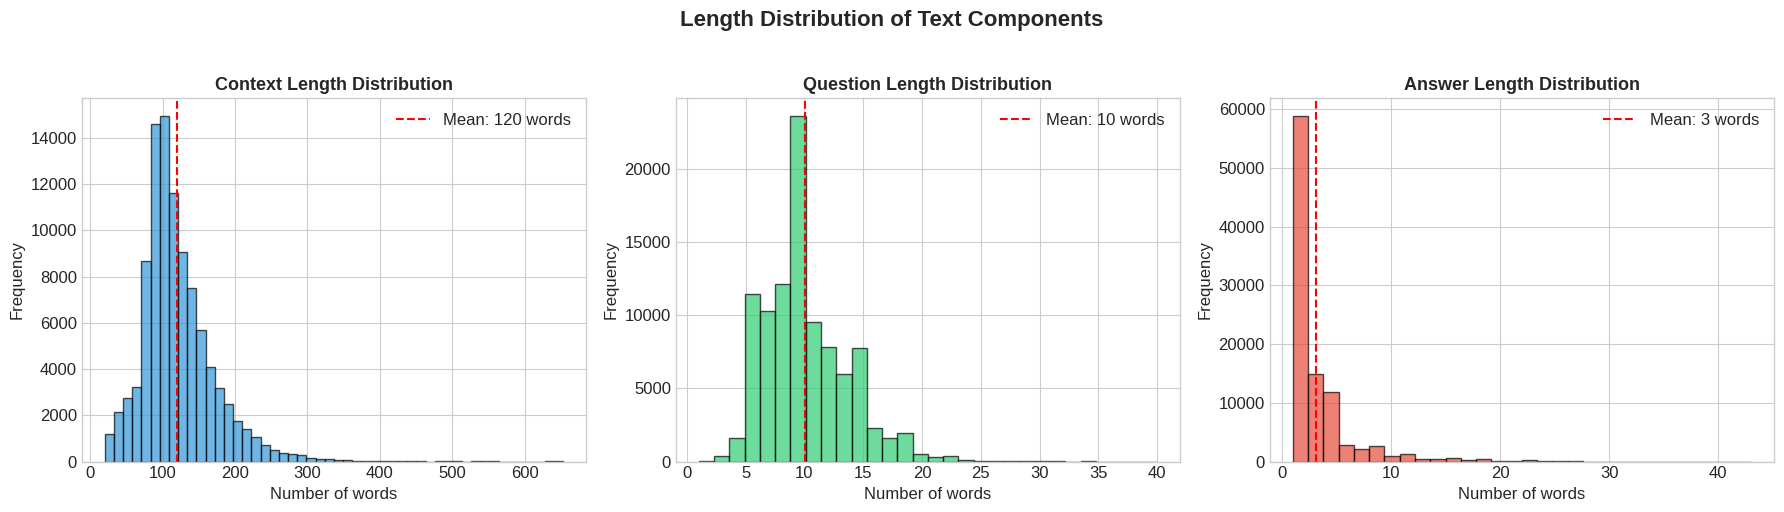

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['context_word_count'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df['context_word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['context_word_count'].mean():.0f} words")
axes[0].set_title('Context Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['question_word_count'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(df['question_word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['question_word_count'].mean():.0f} words")
axes[1].set_title('Question Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].hist(df['answer_word_count'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[2].axvline(df['answer_word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['answer_word_count'].mean():.0f} words")
axes[2].set_title('Answer Length Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of words')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Length Distribution of Text Components', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('text_01_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Phân tích loại câu hỏi

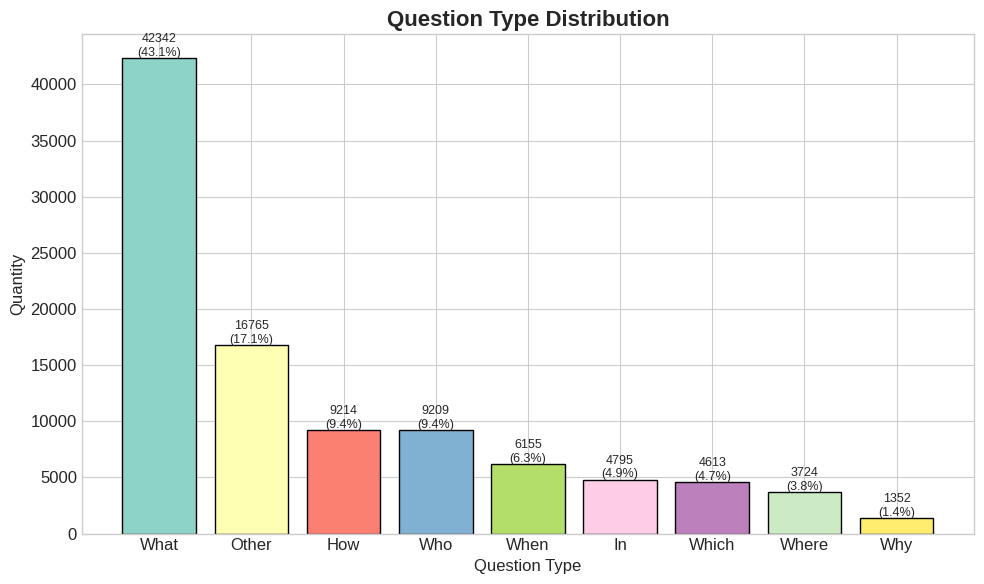

In [7]:
df['question_type'] = df['question'].apply(lambda x: x.split()[0].lower() if len(x.split()) > 0 else '')

main_types = {
    'what': 'What', 'who': 'Who', 'when': 'When', 'where': 'Where',
    'how': 'How', 'which': 'Which', 'why': 'Why', 'in': 'In',
}
df['question_category'] = df['question_type'].map(main_types).fillna('Other')
cat_counts = df['question_category'].value_counts()

plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
bars = plt.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
plt.title('Question Type Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Question Type')
plt.ylabel('Quantity')

for bar, val in zip(bars, cat_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('text_02_question_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top chủ đề có nhiều câu hỏi nhất

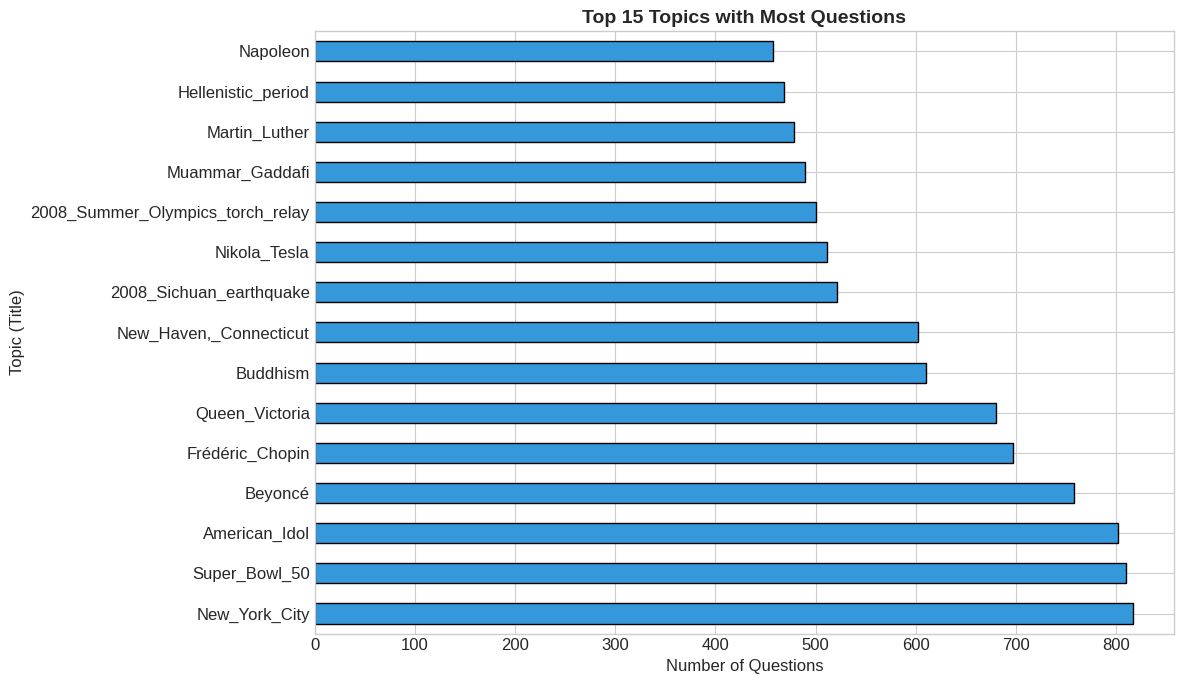

In [8]:
top_titles = df['title'].value_counts().head(15)

plt.figure(figsize=(12, 7))
top_titles.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Top 15 Topics with Most Questions', fontsize=14, fontweight='bold')
plt.xlabel('Number of Questions')
plt.ylabel('Topic (Title)')
plt.tight_layout()
plt.savefig('text_03_top_titles.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Word Cloud

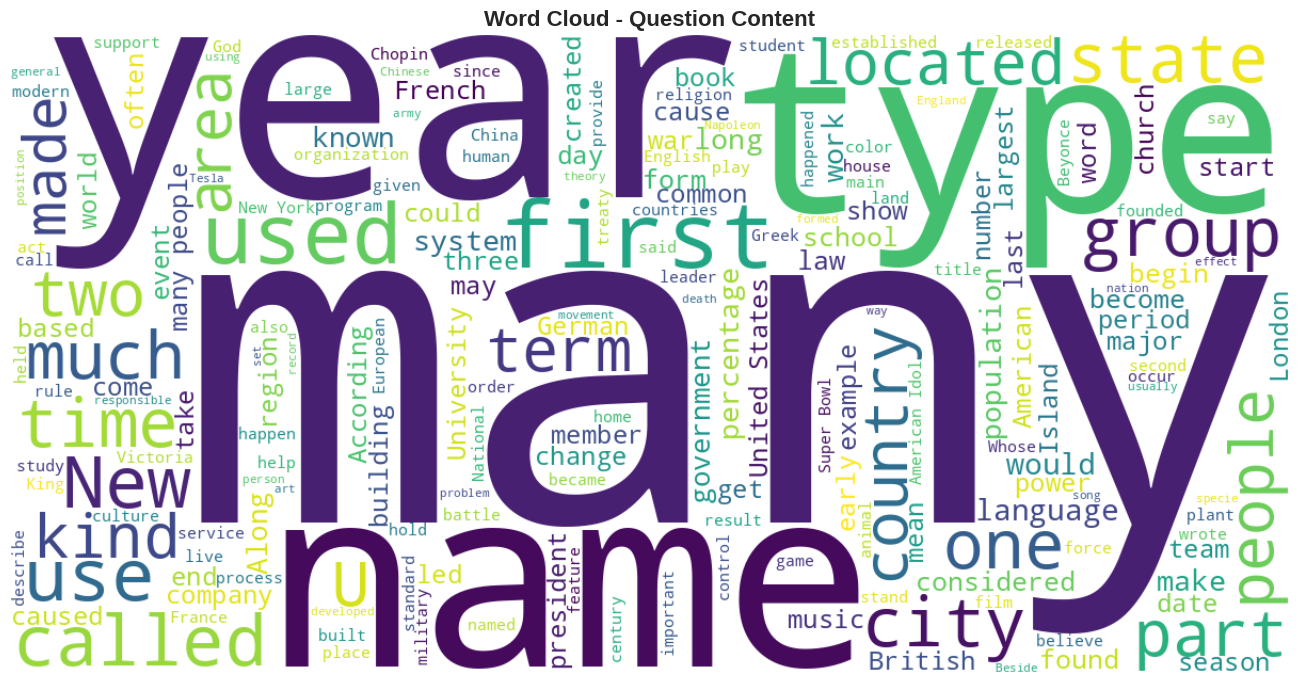

In [9]:
stop_words = set(stopwords.words('english'))
stop_words.update(['what', 'who', 'when', 'where', 'how', 'which', 'why',
                   'the', 'is', 'was', 'did', 'does', 'do', 'are', 'were'])

all_questions = ' '.join(df['question'].values)

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      stopwords=stop_words, max_words=200,
                      colormap='viridis', random_state=42).generate(all_questions)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Question Content', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('text_04_wordcloud_questions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Top từ phổ biến & Vị trí Answer

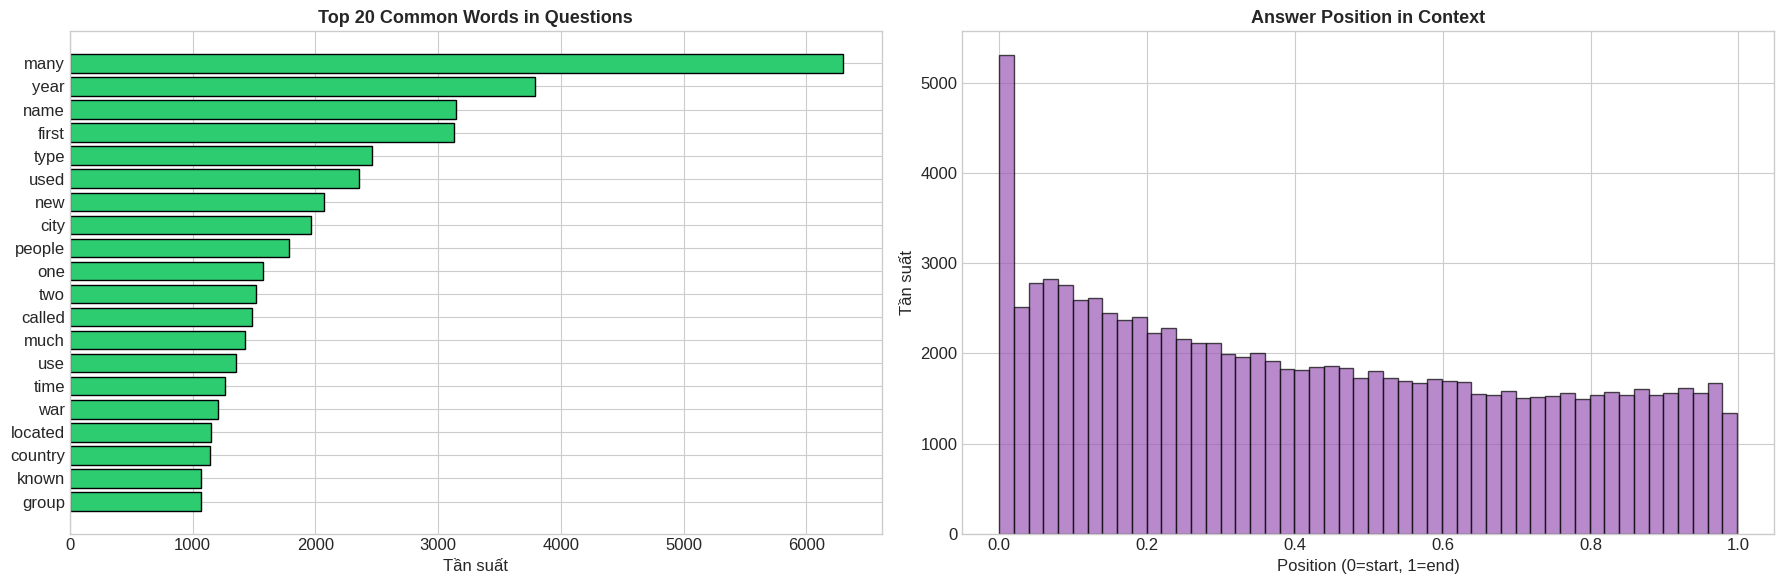

In [10]:
# Top words
all_words = []
for q in df['question']:
    words = re.findall(r'\b[a-z]+\b', q.lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(range(len(words)), counts, color='#2ecc71', edgecolor='black')
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].set_xlabel('Tần suất')
axes[0].set_title('Top 20 Common Words in Questions', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Answer position
df['answer_start'] = df['answers'].apply(lambda x: x['answer_start'][0] if len(x['answer_start']) > 0 else 0)
df['context_char_count'] = df['context'].apply(len)
df['answer_position_ratio'] = df['answer_start'] / df['context_char_count']

axes[1].hist(df['answer_position_ratio'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].set_title('Answer Position in Context', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Position (0=start, 1=end)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('text_05_top_words_and_position.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Tổng kết Findings

**1. TỔNG QUAN:** 87,000+ cặp câu hỏi-trả lời từ 400+ bài viết Wikipedia.

**2. ĐỘ DÀI TEXT:** Context trung bình ~120 từ, Question ~10 từ, Answer rất ngắn (~3 từ).

**3. LOẠI CÂU HỎI:** 'What' chiếm tỷ lệ lớn nhất, tiếp theo là 'How', 'Who', 'When'.

**4. NỘI DUNG:** Chủ đề đa dạng, 1 context có nhiều câu hỏi, answers nằm ở nhiều vị trí.

**5. VẤN ĐỀ:** Dataset chỉ tiếng Anh, answer rất ngắn → phù hợp extractive QA.